# Lagged AR(1) Example
This notebook builds two autocorrelated time series with a known lag, computes the cross-correlation, and compares Pearson and Ebisuzaki significance results.

## 1. Imports
Keep the notebook dependencies explicit so it is clear which pieces come from the package and which plotting helper is local to this notebook.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from autocorrstats import AR1_process, cross_correlation, maximum_cross_correlation
from correlation_plotting import plot_cross_correlation


## 2. Build a known lagged pair
We generate one base AR(1) process, then slice it into two aligned series so that `ts1` leads `ts2` by a known number of time steps.

In [2]:
n_time = 312
dt = 1.0
true_lag = 36
rho = 0.9
sigma = 1.0

base = AR1_process(rho=rho, sigma=sigma, y0=1.0, N=n_time + true_lag, seed=123, dt=dt)

# Align both series on the same time coordinate after introducing a known lag.
ts1 = base.shift(time=-true_lag).dropna('time')
ts2 = base.isel(time=slice(None, -true_lag))

print(f'ts1 shape: {ts1.shape}, ts2 shape: {ts2.shape}')
print(f'Known lag: {true_lag} time steps')

ts1 shape: (312,), ts2 shape: (312,)
Known lag: 36 time steps


## 3. Plot the two series
The offset should be visible directly in the time domain before looking at the correlation function.

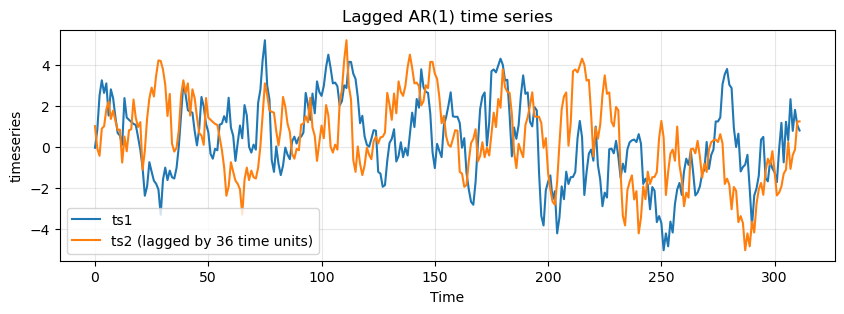

In [3]:
fig, ax = plt.subplots(figsize=(10, 3))
ts1.plot(ax=ax, label='ts1', color='C0')
ts2.plot(ax=ax, label=f'ts2 (lagged by {true_lag} time units)', color='C1')
ax.set_title('Lagged AR(1) time series')
ax.set_xlabel('Time')
ax.legend()
ax.grid(alpha = 0.3)

## 5. Compare Pearson and Ebisuzaki significance
Pearson gives an analytic approximation. Ebisuzaki compares the observed cross-correlation to phase-scrambled surrogate series that preserve the power spectrum.

In [4]:
max_lag = 100
significance_level = 0.05
n_surrogates = 1000

### 1. Calculating ####

pearson_result = cross_correlation(ts1, ts2, maxlags=max_lag, method='pearson')
ebisuzaki_result = cross_correlation(
    ts1,
    ts2,
    maxlags=max_lag,
    method='ebisuzaki',
    n_surrogates=n_surrogates,
    return_distributions=True,
    detrend='linear',
)

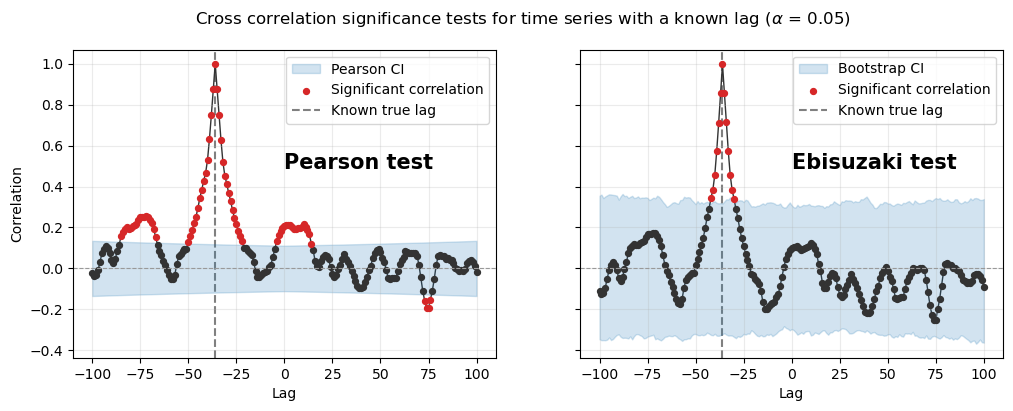

In [5]:
### 2. Plotting ####
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
fig.suptitle('Cross correlation significance tests for time series with a known lag ('  +r'$\alpha$' + f' = {significance_level})')

add_title = lambda ax, title: ax.text(0.5, 0.6, title, transform=ax.transAxes, ha="left", va="bottom", fontweight = "bold", fontsize = 15)

add_title(axes[0], "Pearson test")
plot_cross_correlation(
    pearson_result,
    ax=axes[0],
    significance_level=significance_level,
    show_significance=True,
    show_pearson_confidence=True,
)


add_title(axes[1], "Ebisuzaki test")

plot_cross_correlation(
    ebisuzaki_result,
    ax=axes[1],
    significance_level=significance_level,
    show_significance=True,
    show_confidence=True,
)
axes[1].set_ylabel('')

for ax in axes:
    ax.axvline(-36, label = "Known true lag", zorder = 0, c = "grey", linestyle = "--")
    ax.legend(loc='upper right')


